<a href="https://colab.research.google.com/github/jenenajom/jamystack/blob/main/SHESAFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/mikel-brostrom/Yolov5_DeepSort_Pytorch.git
%cd Yolov5_DeepSort_Pytorch


Cloning into 'Yolov5_DeepSort_Pytorch'...
remote: Enumerating objects: 18383, done.
remote: Counting objects: 100% (521/521), done.
remote: Compressing objects: 100% (245/245), done.
remote: Total 18383 (delta 391), reused 276 (delta 276), pack-reused 17862 (from 3)
Receiving objects: 100% (18383/18383), 128.64 MiB | 19.57 MiB/s, done.
Resolving deltas: 100% (11820/11820), done.
/content/Yolov5_DeepSort_Pytorch


In [4]:
!pip install torch torchvision torchaudio
!pip install opencv-python matplotlib
!pip install yolov5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [8]:
from google.colab import files
uploaded = files.upload()


Saving harrogate-town-stadium-480x320.webp to harrogate-town-stadium-480x320.webp


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-7-19 Python-3.11.13 torch-2.6.0+cu124 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


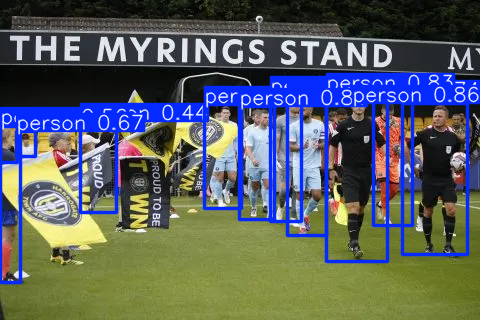

In [14]:
import torch
from pathlib import Path

# Define the path to the video or image file
video_path = 'harrogate-town-stadium-480x320.webp'

# Load model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', trust_repo=True)
model.conf = 0.3  # Confidence threshold
model.classes = [0]  # Only detect 'person' class

# Run detection
results = model(video_path if video_path.endswith('.jpg') or video_path.endswith('.webp') else Path(video_path))

# Display results (for images)
if video_path.endswith('.jpg') or video_path.endswith('.webp'):
    results.show()

In [15]:
detections = results.pred[0]  # Tensor with [x1, y1, x2, y2, confidence, class]
person_count = len(detections)
print(f"Number of people detected: {person_count}")


Number of people detected: 11


In [16]:
for i, (*xyxy, conf, cls) in enumerate(detections):
    print(f"Person {i+1}: Box={xyxy}, Confidence={conf.item():.2f}")


Person 1: Box=[tensor(402.44919), tensor(103.74464), tensor(467.25397), tensor(254.24469)], Confidence=0.86
Person 2: Box=[tensor(239.51120), tensor(106.77985), tensor(274.08362), tensor(219.79822)], Confidence=0.84
Person 3: Box=[tensor(326.53915), tensor(91.43649), tensor(387.14212), tensor(261.12137)], Confidence=0.83
Person 4: Box=[tensor(287.25073), tensor(100.89961), tensor(326.42337), tensor(235.82626)], Confidence=0.81
Person 5: Box=[tensor(373.27002), tensor(98.99477), tensor(412.06671), tensor(225.49768)], Confidence=0.74
Person 6: Box=[tensor(16.14152), tensor(131.45721), tensor(35.42385), tensor(156.53448)], Confidence=0.67
Person 7: Box=[tensor(270.04297), tensor(94.02457), tensor(301.96576), tensor(221.66960)], Confidence=0.66
Person 8: Box=[tensor(204.25534), tensor(104.71482), tensor(241.19247), tensor(208.26123)], Confidence=0.65
Person 9: Box=[tensor(0.29455), tensor(125.13550), tensor(17.25825), tensor(162.59033)], Confidence=0.56
Person 10: Box=[tensor(0.), tensor(1

In [34]:
!rm -f *.jpg *.png *.mp4 *.avi *.mov


In [35]:
from google.colab import files
uploaded = files.upload()

video_path = list(uploaded.keys())[0]
print("File uploaded:", video_path)


Saving Video_Shows_Suspect_Harassing_Woman_In_Queens.mp4 to Video_Shows_Suspect_Harassing_Woman_In_Queens.mp4
File uploaded: Video_Shows_Suspect_Harassing_Woman_In_Queens.mp4


In [37]:
import cv2
import numpy as np

cap = cv2.VideoCapture(video_path)
fgbg = cv2.createBackgroundSubtractorMOG2()
crowd_threshold = 10  # You can adjust this value
harassment_frames = []
frame_num = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_num += 1

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model(rgb_frame, size=640)

    # Count number of people
    person_count = sum([1 for *box, conf, cls in results.xyxy[0] if int(cls) == 0])

    # Detect motion using background subtraction
    fgmask = fgbg.apply(frame)
    movement = np.sum(fgmask > 200)
    harassment_detected = movement > 10000  # Adjust this threshold if needed

    if person_count > crowd_threshold and harassment_detected:
        print(f"🚨 Frame {frame_num}: {person_count} people and possible harassment!")
        harassment_frames.append(frame_num)

cap.release()
print("🚩 Harassment-like frames detected:", harassment_frames)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.am

🚩 Harassment-like frames detected: []


In [31]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)
for fc in harassment_frames[:3]:  # Show first 3 flagged frames
    cap.set(cv2.CAP_PROP_POS_FRAMES, fc)
    ret, frame = cap.read()
    if ret:
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Frame {fc}")
        plt.axis('off')
        plt.show()
cap.release()
